# Phase 1 - Data Cleansing

Goal: Read the raw CSV files from data collection and produce a clean event table for downstream analysis.

## What I noticed during data collection 
Data collection never went smoothly, it was interrupted for a lot of reasons.
<br>Therefore, I decided to use a relatively less-interrupted data that continued 4+ hours without cut, which is in the folder called "20260504_130410"
<br> Also, I noticed two things: 
<br> - The same bubble was counted multiple times although I want to count it as one. Therefore, I need to reduce duplicated bubbles in data cleansing section.
<br> - I stirred sake several tiems to activate fermentation and the movement of my hands are captured as numerous number of bubble movement, so I need to exclude them. 

<br>
Step in this notebook:

1. **1.0 Load and merge chuncks** - combine all 9 chuncks into one DataFrame
2. **1.1 Timestamp normalization** - make timestamp consistent across chunks
3. **1.2 Initial overview** - check the data with raw plots
3. **1.3 Deduplication** - collapse repeated detections of the same bubble
4. **1.4 Anomaly removal** - exclude time intervals with abnormally high detection counts
5. **1.5 Validation** - compare before vs after
6. **1.6 Save clean data** - write CSVs for phase 2 onward

Session used: "20260504_130410" (4h 27min, 9 chunks)

## 0. Setup

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option('display.width', 200)

In [48]:
# Paths
DATA_DIR = '../data/session_20260504_130410'
DATA_CLEAN_DIR = '../data_clean'
OUTPUT_PLOT_DIR = '../outputs/plots'

print('DATA_DIR :', DATA_DIR)
print('DATA_CLEAN_DIR :', DATA_CLEAN_DIR)
print('OUTPUT_PLOT_DIR :', OUTPUT_PLOT_DIR)

DATA_DIR : ../data/session_20260504_130410
DATA_CLEAN_DIR : ../data_clean
OUTPUT_PLOT_DIR : ../outputs/plots


## 1.0 Load and merge chunks
I have 9 chunk CSV files (one per 30-minute segment). Read each one, then concatenate into a single DataFrame.

In [3]:
all_csv_pattern = os.path.join(DATA_DIR, "chunk_*_all_events.csv")
all_csv_files = sorted(glob.glob(all_csv_pattern))

print(f'Found {len(all_csv_files)} all_events CSVs:')
for f in all_csv_files:
    print(f' {os.path.basename(f)}')

Found 9 all_events CSVs:
 chunk_001_all_events.csv
 chunk_002_all_events.csv
 chunk_003_all_events.csv
 chunk_004_all_events.csv
 chunk_005_all_events.csv
 chunk_006_all_events.csv
 chunk_007_all_events.csv
 chunk_008_all_events.csv
 chunk_009_all_events.csv


In [4]:
# read each chunk and concatenate
dfs = []

for filepath in all_csv_files:
    df_chunk = pd.read_csv(filepath)
    dfs.append(df_chunk)
    print(f' {os.path.basename(filepath)}: {len(df_chunk): >6} rows')

df_all = pd.concat(dfs, ignore_index = True)
print(f'\nTotal: {len(df_all):,} rows merged from {len(dfs)} chunks')

 chunk_001_all_events.csv:  31460 rows
 chunk_002_all_events.csv:   2501 rows
 chunk_003_all_events.csv:   4511 rows
 chunk_004_all_events.csv:   2132 rows
 chunk_005_all_events.csv:  21573 rows
 chunk_006_all_events.csv:   2657 rows
 chunk_007_all_events.csv:   6045 rows
 chunk_008_all_events.csv:   1311 rows
 chunk_009_all_events.csv:  14626 rows

Total: 86,816 rows merged from 9 chunks


In [5]:
df_all.head()

,frame_idx,iso_time,timestamp,t_rel,event_id,selected_event_id,cx,cy,x,y,w,h,area,angle,group,selected,reject_reason,reject_detail
0,1,2026-05-04T13:04:11.516378,1.777914e+09,0.394351,1,NaN,320,240,0,0,640,480,306081.0,116.565051,biwa,0,area_over_max,area=306081.0 > MAX_AREA=40
1,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,2,NaN,336,436,333,435,6,3,8.0,165.465545,kakko,0,too_many_contours,"cnts=26, threshold=20"
2,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,3,NaN,348,430,345,428,7,5,13.0,162.057553,kakko,0,too_many_contours,"cnts=26, threshold=20"
3,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,4,NaN,411,396,403,390,16,12,93.5,143.339019,biwa,0,too_many_contours,"cnts=26, threshold=20"
4,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,5,NaN,437,373,428,364,18,19,98.0,134.260741,biwa,0,too_many_contours,"cnts=26, threshold=20"


In [6]:
print('Columns: ', list(df_all.columns))
print('\nData types:')
print(df_all.dtypes)

Columns:  ['frame_idx', 'iso_time', 'timestamp', 't_rel', 'event_id', 'selected_event_id', 'cx', 'cy', 'x', 'y', 'w', 'h', 'area', 'angle', 'group', 'selected', 'reject_reason', 'reject_detail']

Data types:
frame_idx              int64
iso_time                 str
timestamp            float64
t_rel                float64
event_id               int64
selected_event_id    float64
cx                     int64
cy                     int64
x                      int64
y                      int64
w                      int64
h                      int64
area                 float64
angle                float64
group                    str
selected               int64
reject_reason            str
reject_detail            str
dtype: object


# 1.1 Timestamp normalization

In [7]:
df_all

,frame_idx,iso_time,timestamp,t_rel,event_id,selected_event_id,cx,cy,x,y,w,h,area,angle,group,selected,reject_reason,reject_detail
0,1,2026-05-04T13:04:11.516378,1.777914e+09,0.394351,1,NaN,320,240,0,0,640,480,306081.0,116.565051,biwa,0,area_over_max,area=306081.0 > MAX_AREA=40
1,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,2,NaN,336,436,333,435,6,3,8.0,165.465545,kakko,0,too_many_contours,"cnts=26, threshold=20"
2,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,3,NaN,348,430,345,428,7,5,13.0,162.057553,kakko,0,too_many_contours,"cnts=26, threshold=20"
3,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,4,NaN,411,396,403,390,16,12,93.5,143.339019,biwa,0,too_many_contours,"cnts=26, threshold=20"
4,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,5,NaN,437,373,428,364,18,19,98.0,134.260741,biwa,0,too_many_contours,"cnts=26, threshold=20"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86811,234546,2026-05-04T17:30:59.533310,1.777930e+09,16008.411284,86812,NaN,388,24,383,17,11,15,95.5,28.855661,biwa,0,too_many_contours,"cnts=61, threshold=20"
86812,234546,2026-05-04T17:30:59.533310,1.777930e+09,16008.411284,86813,NaN,293,26,290,17,6,19,37.0,3.833677,biwa,0,too_many_contours,"cnts=61, threshold=20"
86813,234546,2026-05-04T17:30:59.533310,1.777930e+09,16008.411284,86814,NaN,236,26,230,17,12,19,39.5,347.221267,koto,0,too_many_contours,"cnts=61, threshold=20"
86814,234546,2026-05-04T17:30:59.533310,1.777930e+09,16008.411284,86815,NaN,187,26,184,17,6,19,38.5,334.387805,koto,0,too_many_contours,"cnts=61, threshold=20"


In [8]:
df_all = df_all.sort_values(['timestamp', 'event_id']).reset_index(drop=True)
df_all


,frame_idx,iso_time,timestamp,t_rel,event_id,selected_event_id,cx,cy,x,y,w,h,area,angle,group,selected,reject_reason,reject_detail
0,1,2026-05-04T13:04:11.516378,1.777914e+09,0.394351,1,NaN,320,240,0,0,640,480,306081.0,116.565051,biwa,0,area_over_max,area=306081.0 > MAX_AREA=40
1,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,2,NaN,336,436,333,435,6,3,8.0,165.465545,kakko,0,too_many_contours,"cnts=26, threshold=20"
2,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,3,NaN,348,430,345,428,7,5,13.0,162.057553,kakko,0,too_many_contours,"cnts=26, threshold=20"
3,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,4,NaN,411,396,403,390,16,12,93.5,143.339019,biwa,0,too_many_contours,"cnts=26, threshold=20"
4,2,2026-05-04T13:04:11.596125,1.777914e+09,0.474099,5,NaN,437,373,428,364,18,19,98.0,134.260741,biwa,0,too_many_contours,"cnts=26, threshold=20"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86811,234546,2026-05-04T17:30:59.533310,1.777930e+09,16008.411284,86812,NaN,388,24,383,17,11,15,95.5,28.855661,biwa,0,too_many_contours,"cnts=61, threshold=20"
86812,234546,2026-05-04T17:30:59.533310,1.777930e+09,16008.411284,86813,NaN,293,26,290,17,6,19,37.0,3.833677,biwa,0,too_many_contours,"cnts=61, threshold=20"
86813,234546,2026-05-04T17:30:59.533310,1.777930e+09,16008.411284,86814,NaN,236,26,230,17,12,19,39.5,347.221267,koto,0,too_many_contours,"cnts=61, threshold=20"
86814,234546,2026-05-04T17:30:59.533310,1.777930e+09,16008.411284,86815,NaN,187,26,184,17,6,19,38.5,334.387805,koto,0,too_many_contours,"cnts=61, threshold=20"


In [9]:

t0 = df_all["timestamp"].min()
df_all["t_rel"] = df_all["timestamp"] - t0

# Human readable time string (mm.ss. mmm)
df_all["t_str"] = df_all["t_rel"].apply(lambda s: f'{int(s//60):02d}:{s%60:06.3f}')

session_duration = df_all['t_rel'].max()

print(f'Session duration : {session_duration:.1f} sec'
      f'({session_duration/60:.1f} min, {session_duration/3600:.2f} hr)')
print(f'First event : t_rel = {df_all['t_rel'].iloc[0]:.3f}s')
print(f'Last event : t_rel = {df_all['t_rel'].iloc[-1]:.3f}s')
print(f'Total detections : {len(df_all):,}')
print(f'Selected events : {(df_all['selected']==1).sum():,}')

Session duration : 16008.0 sec(266.8 min, 4.45 hr)
First event : t_rel = 0.000s
Last event : t_rel = 16008.017s
Total detections : 86,816
Selected events : 5,401


## 1.2 Initial overveiew of raw data

Before cleansing, I will look at:
- The detection density over time (events per minute)
- The instrument group distribution
- The bubble size distribution

<function matplotlib.pyplot.show(close=None, block=None)>

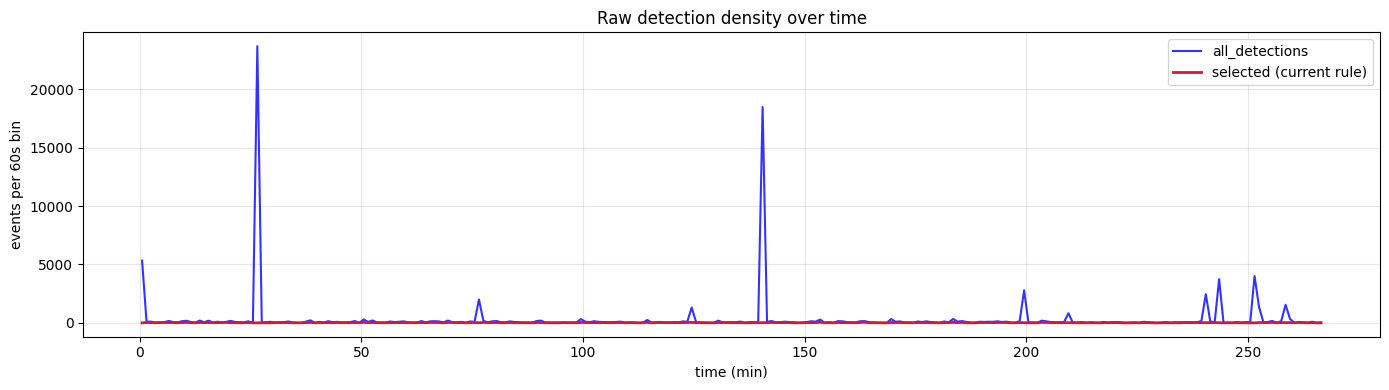

In [10]:
# Detection density: events per minute, in 1-minute bins
bin_sec = 60
edges = np.arange(0, df_all['t_rel'].max() + bin_sec, bin_sec)
h_all, _ = np.histogram(df_all['t_rel'], bins=edges)
h_sel, _ = np.histogram(df_all[df_all['selected']==1]['t_rel'], bins=edges)
centers_min = (edges[:-1] + edges[1:]) / 2 / 60.0

fig, ax = plt.subplots (figsize=(14,4))
ax.plot(centers_min, h_all, label='all_detections', color='blue', alpha=0.8)
ax.plot(centers_min, h_sel, label='selected (current rule)', color='crimson', lw=2)
ax.set_xlabel('time (min)')
ax.set_ylabel(f'events per {bin_sec}s bin')
ax.set_title('Raw detection density over time')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOT_DIR, '01_raw_density.png'), dpi=120)
plt.show

As expected, there are spikes in all_detections although 'selected' filtered out those bursts.
<br>However, to make a model, I need to delete the effect of those spikes, so I will adjust the data later in this phase.

In [11]:
# Instrument group distribution
print('Group distribution (all detections):')
print(df_all['group'].value_counts(normalize=True).round(3))
print()
print('Group distribution (selected events):')
print(df_all[df_all['selected']==1]['group'].value_counts(normalize=True).round(3))

Group distribution (all detections):
group
koto     0.464
biwa     0.362
kakko    0.062
taiko    0.059
shoko    0.053
Name: proportion, dtype: float64

Group distribution (selected events):
group
biwa     0.412
koto     0.360
kakko    0.096
taiko    0.069
shoko    0.064
Name: proportion, dtype: float64


Interestingly, the group distribution are as expected - biwa and koto are 40% and other purcussions account for 20%!

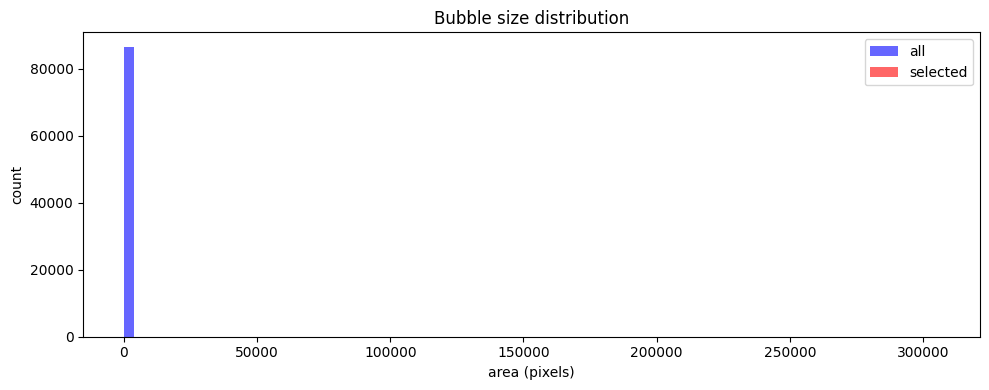

Area statistics (all):
count     86816.00
mean        130.67
std        2515.70
min           8.00
25%          10.00
50%          15.00
75%          27.00
max      306081.00
Name: area, dtype: float64


In [12]:
# Bubble size distribution (area)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_all['area'], bins=80, alpha=0.6, label='all', color='blue')
ax.hist(df_all[df_all['selected']==1]['area'], bins=80, alpha=0.6, label='selected', color='red')
ax.set_xlabel('area (pixels)')
ax.set_ylabel('count')
ax.set_title('Bubble size distribution')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOT_DIR, '02_raw_area_distribution.png'), dpi=120)
plt.show()

print('Area statistics (all):')
print(df_all['area'].describe().round(2))

Since the change of the lighting and other changes that are not bubbles were also recorded, I will see the rejection reason.

In [13]:
# What were the bubbles rejected for?
print('reject_reason counts:')
print(df_all['reject_reason'].value_counts())

print('\nArea by reject_reason:')
print(df_all.groupby('reject_reason')['area'].describe().round(1))

reject_reason counts:
reject_reason
too_many_contours                       60391
global_suppression                       7358
global_suppression;too_many_contours     7049
no_slots_existing                        5492
too_close_to_selected                     669
area_over_max                             190
too_many_contours;no_slots_existing       166
no_slots_after_selection                  100
Name: count, dtype: int64

Area by reject_reason:
                                        count    mean      std   min   25%   50%   75%       max
reject_reason                                                                                   
area_over_max                           190.0  1692.0  22199.7  40.5  45.0  55.0  77.8  306081.0
global_suppression                     7358.0    15.8     36.0   8.0   9.5  12.0  17.5    2830.0
global_suppression;too_many_contours   7049.0   254.0   3055.4   8.0  11.0  16.5  32.0   74610.0
no_slots_after_selection                100.0    12.8      5.

90% percentile: 54 px
95% percentile: 92 px
99% percentile: 329 px


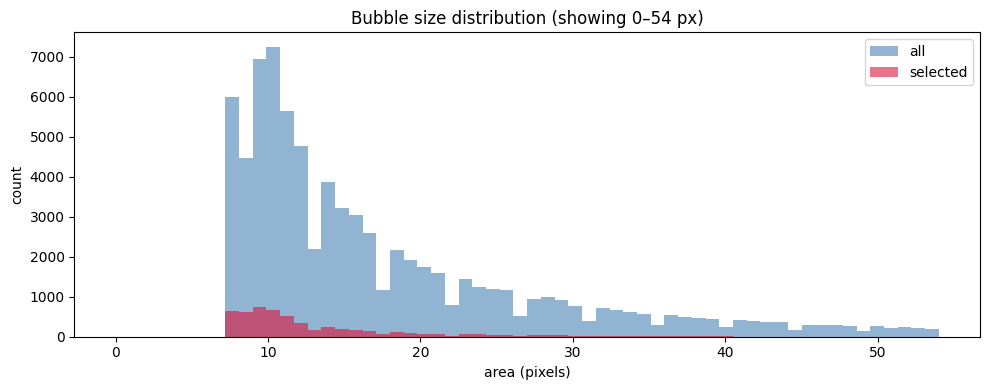


Events above 54 px: 8,670 (9.99%)


In [14]:
import numpy as np

# Setting 90% as max and see histogram
xmax = df_all['area'].quantile(0.90)
print(f'90% percentile: {xmax:.0f} px')
print(f'95% percentile: {df_all["area"].quantile(0.95):.0f} px')
print(f'99% percentile: {df_all["area"].quantile(0.99):.0f} px')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_all['area'], bins=60, range=(0, xmax),
        alpha=0.6, label='all', color='steelblue')
ax.hist(df_all[df_all['selected']==1]['area'], bins=60, range=(0, xmax),
        alpha=0.6, label='selected', color='crimson')
ax.set_xlabel('area (pixels)')
ax.set_ylabel('count')
ax.set_title(f'Bubble size distribution (showing 0–{xmax:.0f} px)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOT_DIR, '02_raw_area_distribution.png'), dpi=120)
plt.show()

# Outlier count
n_outliers = (df_all['area'] > xmax).sum()
print(f'\nEvents above {xmax:.0f} px: {n_outliers:,} ({n_outliers/len(df_all)*100:.2f}%)')

Events with area > 1000 px: 423
Time distribution (in minutes):
count      7.050000
mean     150.254427
std       64.836979
min        0.000000
25%      124.437363
50%      140.685786
75%      199.794050
max      258.531343
Name: t_rel, dtype: float64


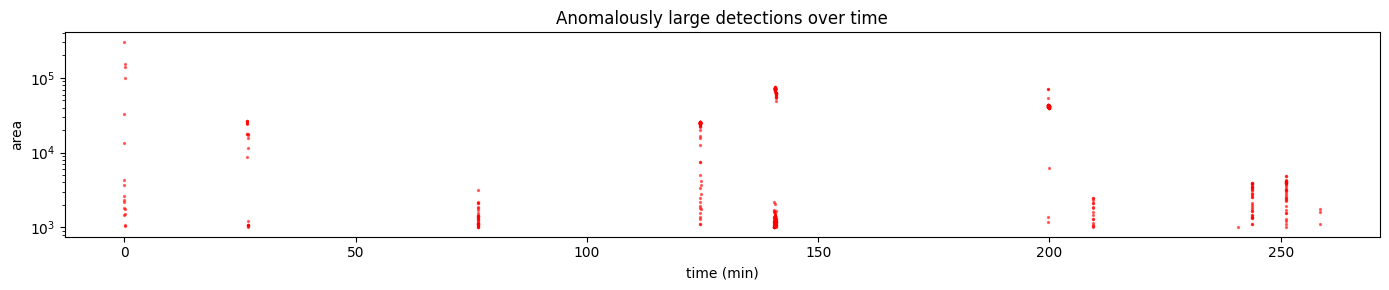

In [15]:
# When do these huge events occur?
huge = df_all[df_all['area'] > 1000]
print(f'Events with area > 1000 px: {len(huge):,}')
print(f'Time distribution (in minutes):')
print(huge['t_rel'].describe()/60)

# Are they concentrated in time?
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 3))
ax.scatter(huge['t_rel']/60, huge['area'], s=2, alpha=0.5, color='red')
ax.set_xlabel('time (min)'); ax.set_ylabel('area')
ax.set_yscale('log')
ax.set_title('Anomalously large detections over time')
plt.tight_layout()
plt.show()

The logic starts rejecting from "too_many_countours", meaning rejects the bubbles when there are too many bubbles.
<br>This is to avoid capturing movements that are unrelated to bubbles 
<br>- so I will delete those data first and come back to see the characteristics of the bubble size later.

## 1.3 Reduce the duplicate counts of bubbles

**Problem**: a single physical bubble that stays on the surface for ~1 second is detected in 5-6 consecutive frames at almost the same position.

**Approach**: spationtemporal clustrering. Two detections belong to the same bubble if:
- their time difference is below 'time_threshold' (0.5s), and
- their spatial distance is below 'space_threshold' (30 px)

I collapse each cluster to one representative bubble (the largest by area).

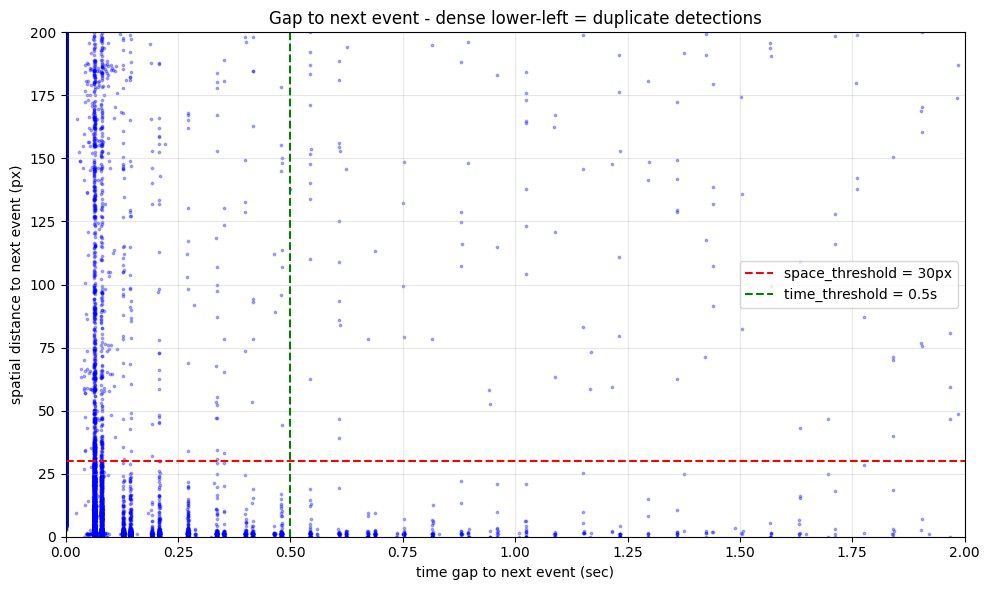

In [16]:
# First, look at the gap to the next event in time and space to decide what thresholds to use

df_sorted = df_all.sort_values(['timestamp', 'event_id']).reset_index(drop=True)
dt = np.diff(df_sorted['t_rel'].values)
dx = np.diff(df_sorted['cx'].values)
dy = np.diff(df_sorted['cy'].values)
ds = np.hypot(dx, dy)

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(dt, ds, s=3, alpha=0.3, color='blue')
ax.axhline(30, color='red', linestyle ='--', label='space_threshold = 30px')
ax.axvline(0.5, color='green', linestyle ='--', label='time_threshold = 0.5s')
ax.set_xlabel('time gap to next event (sec)')
ax.set_ylabel('spatial distance to next event (px)')
ax.set_xlim(0,2)
ax.set_ylim(0,200)
ax.set_title('Gap to next event - dense lower-left = duplicate detections')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOT_DIR, '03_threshold_check.png'), dpi=120)
plt.show()


Remembering how bubbles behave, when the detection happened at almost the same space within 1 second, it's almost the case that the system detects the same bubble. 
<br>Therefore, I increase the time threshold to 1.0s
<br>
<br>I will see if I can delete the plots below 0.2 by deleting the bubble spike. If not, I will need to deduplicate again.

In [17]:
def deduplicate_bubbles (df, time_threshold=1.0, space_threshold=30.0):
    df = df.sort_values(['timestamp', 'event_id']).reset_index(drop=True).copy()
    n = len(df)
    cluster_ids =np.full(n, -1, dtype=int)
    next_cluster_id = 0

    t_arr = df['t_rel'].values
    cx_arr = df['cx'].values
    cy_arr = df['cy'].values

    for i in range(n):
        if cluster_ids[i] !=-1:
            continue
        cluster_ids[i] = next_cluster_id
        ti, cxi, cyi = t_arr[i], cx_arr[i], cy_arr[i]

        for j in range (i +1, n):
            if t_arr[j] - ti > time_threshold:
                break
            if cluster_ids[j] != -1:
                continue
            d = np.hypot(cxi - cx_arr[j], cyi - cy_arr[j])
            if d <= space_threshold:
                cluster_ids[j] = next_cluster_id
        next_cluster_id += 1
    
    df['cluster_id'] = cluster_ids
    cluster_sizes = df.groupby('cluster_id').size()
    df['cluster_size'] = df['cluster_id'].map(cluster_sizes)

    def pick_representative(group):
        if (group['selected'] ==1).any():
            sub = group[group['selected'] ==1]
            return sub.loc[sub['event_id'].idxmin()]
        return group.loc[group['event_id'].idxmin()]
    
    df_dedup = df.groupby('cluster_id', group_keys=False).apply(pick_representative)
    df_dedup = df_dedup.sort_values(['timestamp', 'event_id']).reset_index(drop=True)
    return df_dedup, df




In [18]:
# Run deduplication 
TIME_THRESHOLD = 0.5
SPACE_THERSHOLD = 30.0

print(f'Running dedup with time_threshold={TIME_THRESHOLD}s, space_threshold={SPACE_THERSHOLD}px ...')
df_dedup, df_with_cluster = deduplicate_bubbles(df_all, time_threshold=TIME_THRESHOLD, space_threshold=SPACE_THERSHOLD)

print(f'\nBefore dedup : {len(df_all):>7,} events')
print(f'After  dedup : {len(df_dedup):>7,} events')
print(f'Reduction    : {(1 - len(df_dedup)/len(df_all))*100:.1f}%')
print()
print(f'Selected before : {(df_all["selected"]==1).sum():>7,}')
print(f'Selected after  : {(df_dedup["selected"]==1).sum():>7,}')

Running dedup with time_threshold=0.5s, space_threshold=30.0px ...

Before dedup :  86,816 events
After  dedup :   9,483 events
Reduction    : 89.1%

Selected before :   5,401
Selected after  :   2,244


Since time_threshold = 1.0 deletes 93% of the data and the selection ratio over all_bubbles was around 33% (too high), 
<br>I set the time_threshold back to 0.5

In [19]:
# Cluster size distribution: how many duplicates per real bubble?
size_counts = df_with_cluster['cluster_size'].value_counts().sort_index()
print('Cluster size distribution (= how many times each bubble was detected):')
for s, c in size_counts.head(15).items():
    bar = '#' * int(min(60, c / size_counts.max() * 60))
    print(f'  size {s:>3} : {c:>7,} bubbles  {bar}')

Cluster size distribution (= how many times each bubble was detected):
  size   1 :   1,424 bubbles  #############
  size   2 :   1,558 bubbles  ##############
  size   3 :   1,767 bubbles  ################
  size   4 :   2,132 bubbles  ###################
  size   5 :   2,365 bubbles  #####################
  size   6 :   2,958 bubbles  ###########################
  size   7 :   3,829 bubbles  ###################################
  size   8 :   6,536 bubbles  ############################################################
  size   9 :   3,330 bubbles  ##############################
  size  10 :   3,430 bubbles  ###############################
  size  11 :   3,641 bubbles  #################################
  size  12 :   4,080 bubbles  #####################################
  size  13 :   3,497 bubbles  ################################
  size  14 :   3,724 bubbles  ##################################
  size  15 :   3,510 bubbles  ################################


## 1.4 Abnormaly removal

**Problem**: during the recording, water was added a few tiems. This caused brief periods with abnormally high detection counts (waves, splashing, lighting changes)

**Approach**: 
1. Compute detections per second on the deduplicated data.
2. Identify seconds with count > threshold.
3. Mark those tiem intervals as excluded (rather than deleting events)

In [22]:
# per-second detection count 
session_max = df_dedup['t_rel'].max()
edges_1s = np.arange(0, session_max+1, 1)
counts_per_sec, _ = np.histogram(df_dedup['t_rel'], bins=edges_1s)
centers_sec_min = (edges_1s[:-1] + edges_1s[1:]) / 2 / 60.0

print(f'Per-second statistics (after deduplication):')
print(f'mean : {counts_per_sec.mean():.2f} events/sec')
print(f'median : {np.median(counts_per_sec):.2f} ')
print(f'std : {counts_per_sec.std():.2f} ')
print(f'max : {counts_per_sec.max()} ')
print(f'99%ile : {np.percentile(counts_per_sec, 99):.1f} ')
print(f'99.5% : {np.percentile(counts_per_sec, 99.5):.1f} ')


Per-second statistics (after deduplication):
mean : 0.59 events/sec
median : 0.00 
std : 6.00 
max : 200 
99%ile : 3.0 
99.5% : 11.0 


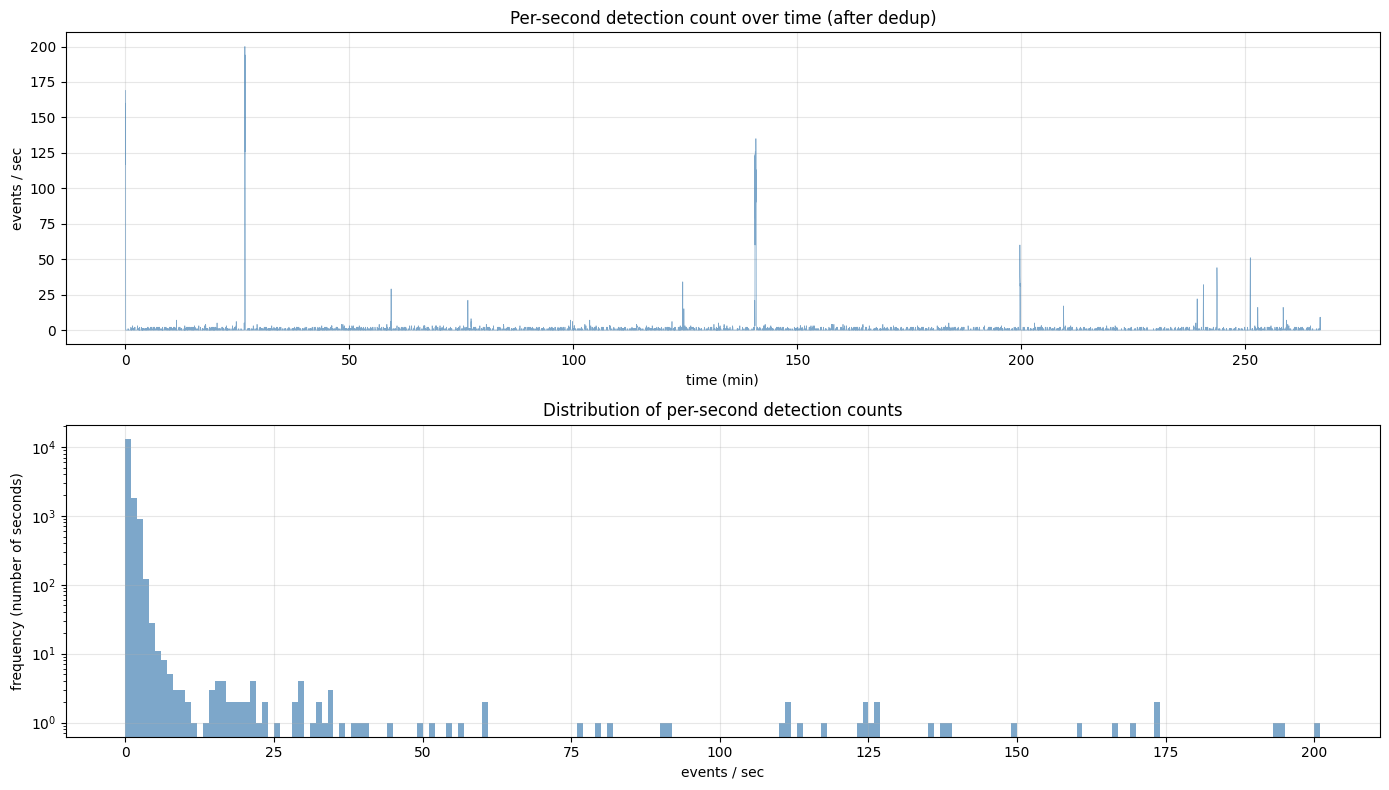

In [33]:
# Plot 1: time series of per-second counts
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(centers_sec_min, counts_per_sec, lw=0.5, color='steelblue', alpha=0.7)
axes[0].set_xlabel('time (min)')
axes[0].set_ylabel('events / sec')
axes[0].set_title('Per-second detection count over time (after dedup)')
axes[0].grid(alpha=0.3)

# Plot 2: histogram of per-second counts (log scale on y)
axes[1].hist(counts_per_sec, bins=range(0, int(counts_per_sec.max())+2),
             color='steelblue', alpha=0.7)
axes[1].set_xlabel('events / sec')
axes[1].set_ylabel('frequency (number of seconds)')
axes[1].set_yscale('log')
axes[1].set_title('Distribution of per-second detection counts')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOT_DIR, '04_per_second_counts.png'), dpi=120)
plt.show()

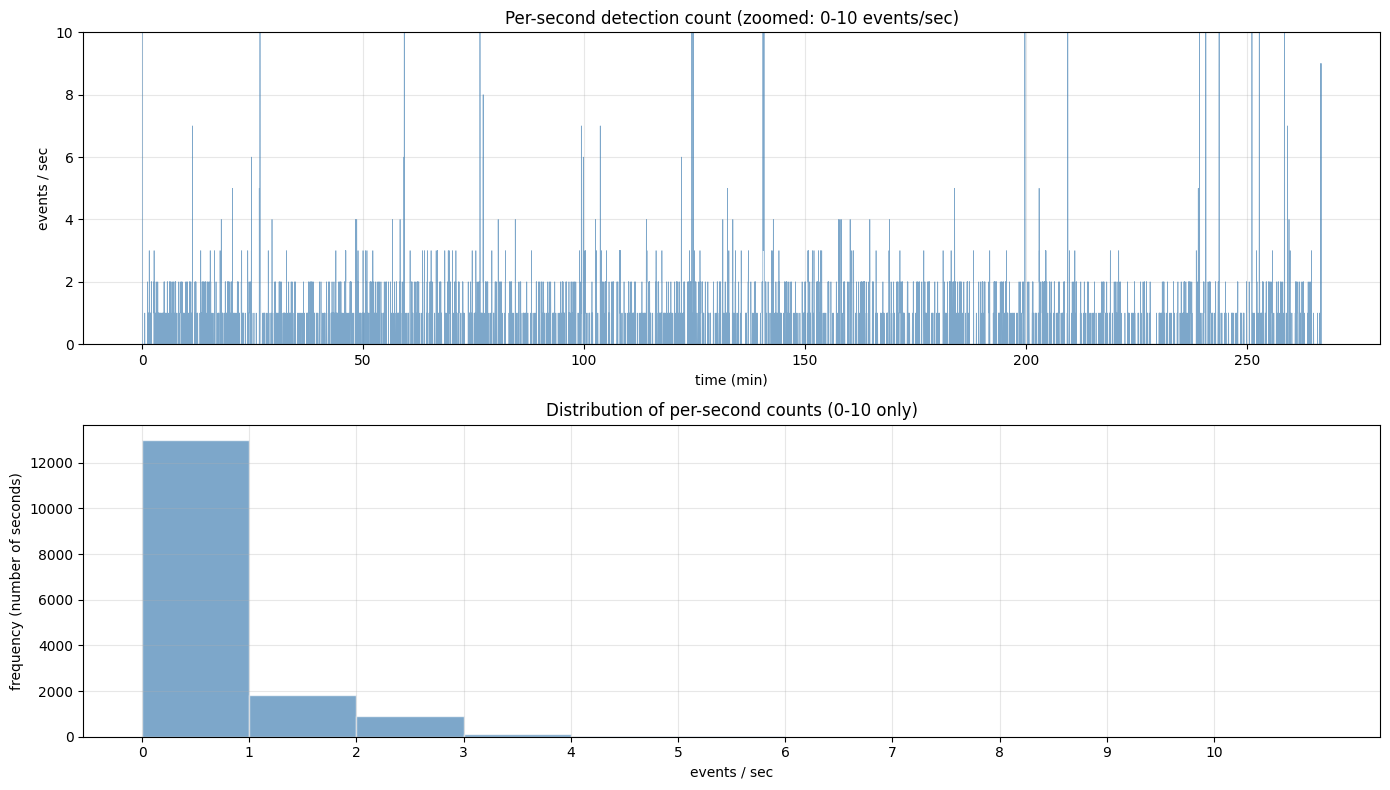

Distribution of per-second counts (after dedup):
   0 events/sec : 13,012 seconds (81.28%)  ############################################################
   1 events/sec :  1,829 seconds (11.42%)  ########
   2 events/sec :    906 seconds ( 5.66%)  ####
   3 events/sec :    121 seconds ( 0.76%)  
   4 events/sec :     28 seconds ( 0.17%)  
   5 events/sec :     11 seconds ( 0.07%)  
   6 events/sec :      8 seconds ( 0.05%)  
   7 events/sec :      5 seconds ( 0.03%)  
   8 events/sec :      3 seconds ( 0.02%)  
   9 events/sec :      3 seconds ( 0.02%)  
  10 events/sec :      2 seconds ( 0.01%)  

>10 events/sec: 81 seconds


In [34]:
# Zoom in on the baseline (0-10 events/sec) to see the actual fermentation rhythm
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# (1) Time series with y-axis clipped to 10
axes[0].plot(centers_sec_min, counts_per_sec, lw=0.5, color='steelblue', alpha=0.7)
axes[0].set_xlabel('time (min)')
axes[0].set_ylabel('events / sec')
axes[0].set_title('Per-second detection count (zoomed: 0-10 events/sec)')
axes[0].set_ylim(0, 10)   # ← clip y-axis here
axes[0].grid(alpha=0.3)

# (2) Distribution within 0-10 range
mask = counts_per_sec <= 10
axes[1].hist(counts_per_sec[mask],
             bins=range(0, 12),
             color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('events / sec')
axes[1].set_ylabel('frequency (number of seconds)')
axes[1].set_title('Distribution of per-second counts (0-10 only)')
axes[1].set_xticks(range(0, 11))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOT_DIR, '04b_per_second_baseline.png'), dpi=120)
plt.show()

# Print per-second distribution
print('Distribution of per-second counts (after dedup):')
unique, counts = np.unique(counts_per_sec[counts_per_sec <= 10], return_counts=True)
for c, n in zip(unique, counts):
    bar = '#' * int(min(60, n / counts.max() * 60))
    pct = n / len(counts_per_sec) * 100
    print(f'  {c:>2} events/sec : {n:>6,} seconds ({pct:>5.2f}%)  {bar}')

print(f'\n>10 events/sec: {(counts_per_sec > 10).sum():,} seconds')

In [32]:
ANOMALY_THRESHOLD = 10   # adjust based on the plot above

anomaly_seconds = np.where(counts_per_sec > ANOMALY_THRESHOLD)[0]
print(f'Threshold: {ANOMALY_THRESHOLD} events/sec')
print(f'Anomalous seconds: {len(anomaly_seconds)}')
print(f'  -> {len(anomaly_seconds)/3600:.2f} hours of anomaly')
print(f'  -> {len(anomaly_seconds)/len(counts_per_sec)*100:.2f}% of recording')

Threshold: 10 events/sec
Anomalous seconds: 81
  -> 0.02 hours of anomaly
  -> 0.51% of recording


In [37]:
# Group consecutive anomalous seconds into intervals (so we can see them as ranges)
def group_consecutive(arr, max_gap=3):
    """Group seconds into intervals if they are within `max_gap` seconds of each other."""
    if len(arr) == 0:
        return []
    groups = []
    start = arr[0]
    prev = arr[0]
    for s in arr[1:]:
        if s - prev > max_gap:
            groups.append((start, prev))
            start = s
        prev = s
    groups.append((start, prev))
    return groups

intervals = group_consecutive(anomaly_seconds, max_gap=3)
print(f'Anomalous intervals (grouped, gap <= 5s):')
for i, (s, e) in enumerate(intervals[:30]):
    duration = e - s + 1
    print(f'  [{s:>5}s ~ {e:>5}s]  ({s/60:5.1f}min ~ {e/60:5.1f}min)  '
          f'duration {duration}s')
if len(intervals) > 30:
    print(f'  ... and {len(intervals)-30} more')

Anomalous intervals (grouped, gap <= 5s):
  [    0s ~     3s]  (  0.0min ~   0.1min)  duration 4s
  [ 1595s ~  1606s]  ( 26.6min ~  26.8min)  duration 12s
  [ 3560s ~  3560s]  ( 59.3min ~  59.3min)  duration 1s
  [ 4586s ~  4589s]  ( 76.4min ~  76.5min)  duration 4s
  [ 7463s ~  7467s]  (124.4min ~ 124.5min)  duration 5s
  [ 7482s ~  7482s]  (124.7min ~ 124.7min)  duration 1s
  [ 8430s ~  8450s]  (140.5min ~ 140.8min)  duration 21s
  [11984s ~ 11989s]  (199.7min ~ 199.8min)  duration 6s
  [12568s ~ 12569s]  (209.5min ~ 209.5min)  duration 2s
  [14359s ~ 14359s]  (239.3min ~ 239.3min)  duration 1s
  [14440s ~ 14445s]  (240.7min ~ 240.8min)  duration 6s
  [14622s ~ 14627s]  (243.7min ~ 243.8min)  duration 6s
  [15067s ~ 15072s]  (251.1min ~ 251.2min)  duration 6s
  [15169s ~ 15172s]  (252.8min ~ 252.9min)  duration 4s
  [15510s ~ 15513s]  (258.5min ~ 258.6min)  duration 4s


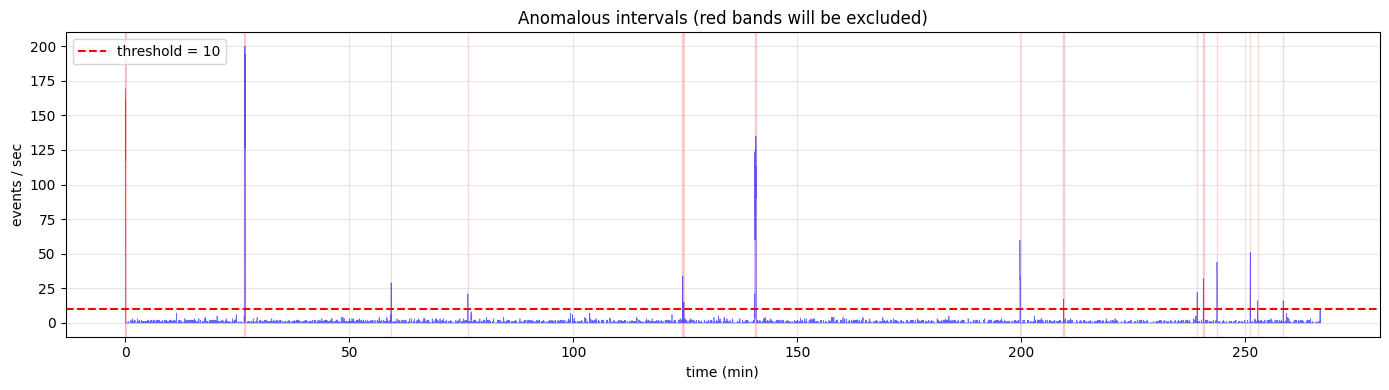

In [39]:
# Visualize anomalous intervals on the time series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(centers_sec_min, counts_per_sec, lw=0.5, color='blue', alpha=0.6)
ax.axhline(ANOMALY_THRESHOLD, color='red', linestyle='--', label=f'threshold = {ANOMALY_THRESHOLD}')
for s, e in intervals:
    ax.axvspan(s/60, (e+1)/60, color='red', alpha=0.15)
ax.set_xlabel('time (min)'); ax.set_ylabel('events / sec')
ax.set_title('Anomalous intervals (red bands will be excluded)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOT_DIR, '05_anomaly_intervals.png'), dpi=120)
plt.show()

In [40]:
# Mark events as in_anomaly (kept in the data, but flagged)
df_dedup['in_anomaly'] = False
for s, e in intervals:
    mask = (df_dedup['t_rel'] >= s) & (df_dedup['t_rel'] < e + 1)
    df_dedup.loc[mask, 'in_anomaly'] = True

n_anomaly_events = df_dedup['in_anomaly'].sum()
print(f'Events flagged as anomaly: {n_anomaly_events:,} ({n_anomaly_events/len(df_dedup)*100:.1f}%)')
print(f'Events kept (clean)      : {(~df_dedup["in_anomaly"]).sum():,}')

Events flagged as anomaly: 5,171 (54.5%)
Events kept (clean)      : 4,312


## 1.5 Validation

I will compare before aand after cleansing to check
- If the overall density profile matches to make sure cleansing only removed noise, not the rhythm structure.
- If the proportions of bubbles in each instrument group are roughly preserved.

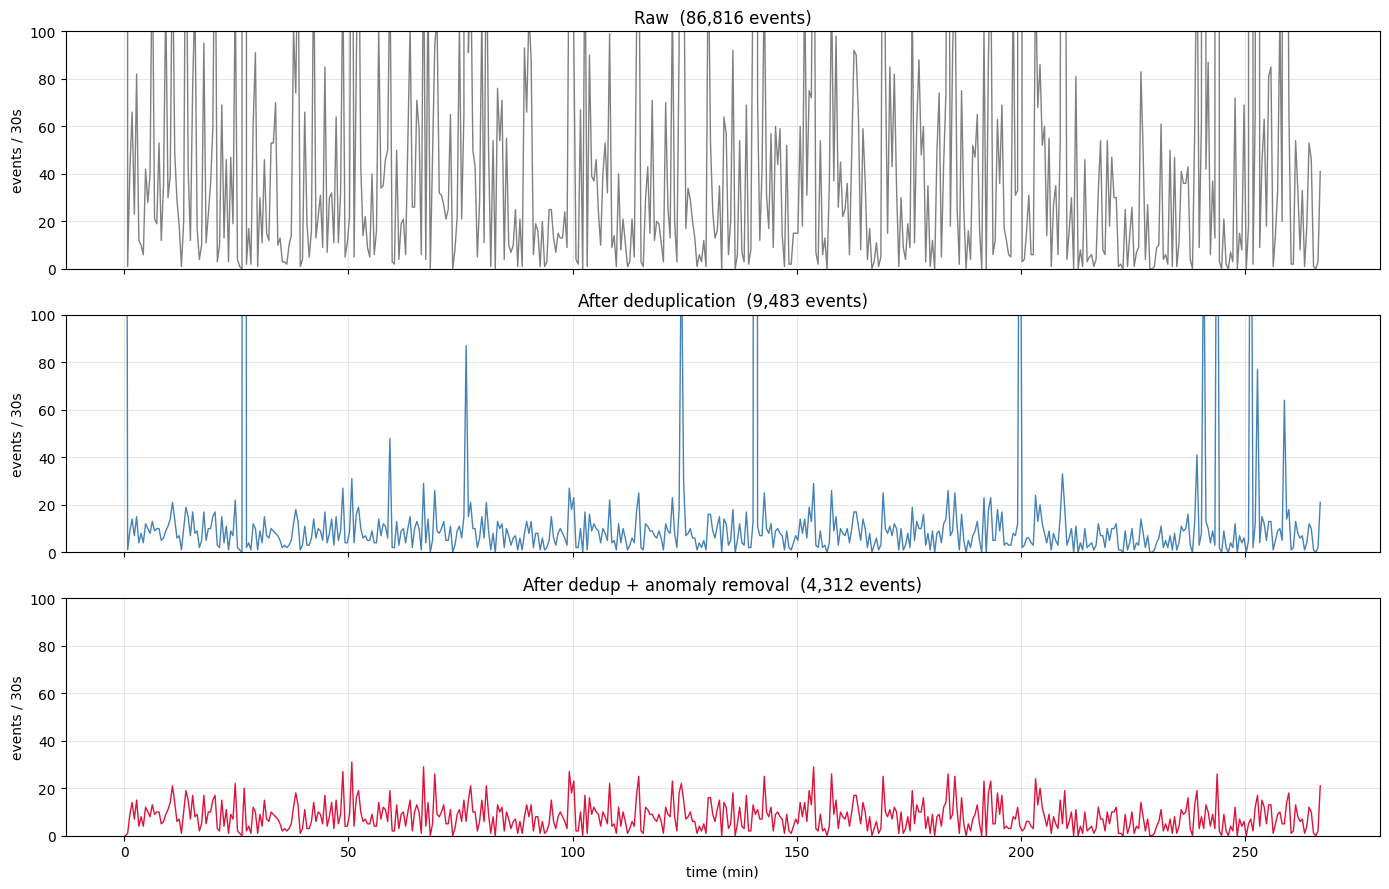

In [45]:
bin_sec = 30
edges = np.arange(0, df_all['t_rel'].max() + bin_sec, bin_sec)
h_raw,    _ = np.histogram(df_all['t_rel'],    bins=edges)
h_dedup,  _ = np.histogram(df_dedup['t_rel'],  bins=edges)
h_clean,  _ = np.histogram(df_dedup[~df_dedup['in_anomaly']]['t_rel'], bins=edges)
centers_min2 = (edges[:-1] + edges[1:]) / 2 / 60.0

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 1) Raw
axes[0].plot(centers_min2, h_raw, color='gray', lw=1)
axes[0].set_ylabel(f'events / {bin_sec}s')
axes[0].set_title(f'Raw  ({len(df_all):,} events)')
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.3)

# 2) After dedup
axes[1].plot(centers_min2, h_dedup, color='steelblue', lw=1)
axes[1].set_ylabel(f'events / {bin_sec}s')
axes[1].set_title(f'After deduplication  ({len(df_dedup):,} events)')
axes[1].set_ylim(0, 100)
axes[1].grid(alpha=0.3)

# 3) After dedup + anomaly removal
axes[2].plot(centers_min2, h_clean, color='crimson', lw=1)
axes[2].set_ylabel(f'events / {bin_sec}s')
axes[2].set_xlabel('time (min)')
axes[2].set_title(f'After dedup + anomaly removal  ({(~df_dedup["in_anomaly"]).sum():,} events)')
axes[2].set_ylim(0, 100)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOT_DIR, '06_validation_density.png'), dpi=120)
plt.show()

Okay, the rhythm is roughly preserved!

In [46]:
# Group distribution comparison
groups = ['biwa', 'koto', 'kakko', 'taiko', 'shoko']

raw_pct   = df_all['group'].value_counts(normalize=True).reindex(groups, fill_value=0)
dedup_pct = df_dedup['group'].value_counts(normalize=True).reindex(groups, fill_value=0)
clean_pct = df_dedup[~df_dedup['in_anomaly']]['group'].value_counts(normalize=True).reindex(groups, fill_value=0)

comparison = pd.DataFrame({
    'raw':   raw_pct,
    'dedup': dedup_pct,
    'clean': clean_pct,
}).round(3)
print('Group distribution at each stage:')
print(comparison)

Group distribution at each stage:
         raw  dedup  clean
group                     
biwa   0.362  0.365  0.418
koto   0.464  0.431  0.367
kakko  0.062  0.073  0.086
taiko  0.059  0.068  0.069
shoko  0.053  0.063  0.061


The instrument group allocation is roughly preserved as well! 

## 1.6 Save clean data

Three CSVs are saved for use by phase 2 and going forward.
1. all_events_clean.csv - main dataset for analysis. Has cluster_id, cluster_size, in_anomaly culumns added.
2. selected_events_clean.csv - subset where selected ==1 (current rule selections, deduplicated, anomaly-flagged)
3. all_events_with_cluster.csv - original events (no dedup) with cluster_id and cluster_size added for debugging.

In [49]:
out_all = os.path.join(DATA_CLEAN_DIR, 'all_events_clean.csv')
out_sel = os.path.join(DATA_CLEAN_DIR, 'selected_events_clean.csv')
out_dbg = os.path.join(DATA_CLEAN_DIR, 'all_events_with_cluster.csv')

df_dedup.to_csv(out_all, index=False)
df_dedup[df_dedup['selected']==1].to_csv(out_sel, index=False)
df_with_cluster.to_csv(out_dbg, index=False)

print(f'Saved:')
print(f'{out_all}({len(df_dedup):,} rows)')
print(f'{out_sel}({(df_dedup["selected"]==1).sum():,} rows)')
print(f'{out_dbg}({len(df_with_cluster):,} rows)')

Saved:
../data_clean/all_events_clean.csv(9,483 rows)
../data_clean/selected_events_clean.csv(2,244 rows)
../data_clean/all_events_with_cluster.csv(86,816 rows)


all_events_clean.csv
- t_rel - seconds from session start
- cx, cy, area, angle , group - bubble properties
- cluster_id, cluster_size - deduplication info (size=1 means no deplicate)
- in_anomaly - true if the event falls in an anomalous time interval (e.g., water added) 